In [2]:
import sys
import datetime as dt
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.resampled_data_loader import get_resampled_quotes

instruments = ['USDSGD', 'EURUSD', 'AUDUSD', 'GBPUSD', 'USDJPY']
ccys = ['USD', 'EUR', 'AUD', 'GBP', 'JPY']

start_date = dt.datetime(2020, 1, 1)
end_date = dt.datetime(2025, 12, 31)
freq = pd.Timedelta(minutes=15)

prices = get_resampled_quotes(instruments, start_date, end_date, freq)

In [33]:
# reload
import importlib

import research.sgd_neer as sn
importlib.reload(sn)

import strategy.sgd_neer_strategy as sns
importlib.reload(sns)

import research.mean_reversion as mr
importlib.reload(mr)

import trading.aggressive_trader as at
importlib.reload(at)

<module 'trading.aggressive_trader' from '/Users/jinliu/Programming/Python/systematic-trading/src/systematic_trading/trading/aggressive_trader.py'>

In [11]:
strategy = sns.SGDNEERStrategy(instruments, prices,
                        {"past_horizon": pd.Timedelta(minutes=120),
                         "zscore_window": pd.Timedelta(days=5),
                         "future_horizon": pd.Timedelta(minutes=15),
                         "zscore_entry_threshold": 1.0,
                         "spread_rolling_window": pd.Timedelta(minutes=60),
                         "margin_multiple":0.5,
                         "adjust_to_target": True,
                         "delay_trade_on_signal": False
                        })


In [12]:
rets_vs_sgd = sn.build_rets_vs_sgd(prices)
index_ret_series = rets_vs_sgd["index"]
currency_ret_series = rets_vs_sgd["EUR"]

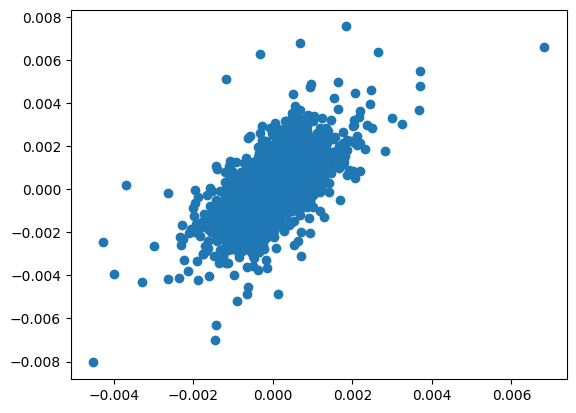

In [13]:
from matplotlib import pyplot as plt
plt.scatter(index_ret_series, currency_ret_series)

<Axes: xlabel='interval_seconds'>

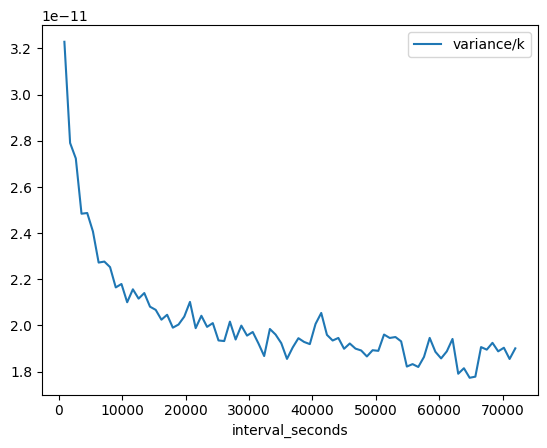

In [14]:
mr.variance_ratio(index_ret_series, pd.Timedelta(seconds=72000)).plot()

In [ ]:
# mean reversion regression stats for the index and each component ccy (SGDXXX)
past_horizons = [
    pd.Timedelta(minutes=15),
    pd.Timedelta(minutes=30),
    pd.Timedelta(minutes=60),
    pd.Timedelta(minutes=120),
]

future_horizons = [
    pd.Timedelta(minutes=15),
    pd.Timedelta(minutes=30),
    pd.Timedelta(minutes=60),
]

rets_vs_sgd = sn.build_rets_vs_sgd(prices)

frames = [
    mr.return_regression_heatmap(
        rets_vs_sgd[ccy], past_horizons, future_horizons, pd.Timedelta(days=5)
    )
    for ccy in rets_vs_sgd.columns
]

pd.concat(frames, axis=0)

,name,past_period,future_period,past_period_seconds,future_period_seconds,abs_z_bucket,correlation,beta,n_observations,r_squared,alpha,p_value,std_err
0,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,0-0.5,-0.041490,-0.130840,66568,0.001721,9.019514e-07,9.215120e-27,0.012212
1,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,0.5-1,-0.086152,-0.110625,40123,0.007422,-2.602923e-07,5.748897e-67,0.006387
2,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,1-2,-0.130425,-0.103759,27247,0.017011,3.030083e-06,1.158207e-103,0.004779
3,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,2-inf,-0.226278,-0.121807,6991,0.051202,-1.622665e-06,7.217445e-82,0.006272
4,index,0 days 00:15:00,0 days 00:30:00,900.0,1800.0,0-0.5,-0.034961,-0.148866,66416,0.001222,7.621835e-07,2.015631e-19,0.016513
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,GBP,0 days 02:00:00,0 days 00:30:00,7200.0,1800.0,2-inf,-0.069248,-0.018119,8718,0.004795,3.171229e-05,9.637493e-11,0.002796
44,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,0-0.5,-0.015152,-0.033109,66026,0.000230,-3.642776e-06,9.883743e-05,0.008503
45,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,0.5-1,-0.025356,-0.025816,37517,0.000643,1.827687e-06,9.020941e-07,0.005255
46,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,1-2,-0.032570,-0.019497,26973,0.001061,1.468185e-06,8.782694e-08,0.003643


In [76]:
results = rolling_panel_regression(index_ret_series, currency_ret_series, future_horizon=pd.Timedelta(minutes=15), lookback_window=pd.Timedelta(days=5))

In [72]:
results.head(5)

,return_past,return_future,index_return_past,ccy_return_past,ccy_return_future,first_stage_beta,first_stage_alpha,residual,beta,residual_beta,index_beta,alpha,correlation,t_stat,prediction,prediction_zscore
timestamp,,,,,,,,,,,,,,,,
2020-01-15 20:00:00-05:00,-0.000043,0.000034,-0.000051,-0.000140,0.000034,1.194473,-0.000036,-0.000043,-0.050057,-0.050057,-0.120683,0.000002,-0.060860,-1.344227,0.000011,-0.057429
2020-01-15 20:15:00-05:00,0.000292,-0.000267,-0.000066,0.000178,-0.000267,1.197442,-0.000035,0.000292,-0.054544,-0.054544,-0.114816,0.000002,-0.066439,-1.466609,-0.000005,-0.901912
2020-01-15 20:30:00-05:00,0.000301,0.000007,-0.000383,-0.000191,0.000007,1.196295,-0.000034,0.000301,-0.053137,-0.053137,-0.116045,0.000001,-0.064749,-1.429438,0.000029,0.953801
2020-01-15 20:45:00-05:00,0.000177,0.000167,-0.000385,-0.000318,0.000167,1.200147,-0.000033,0.000177,-0.051631,-0.051631,-0.119103,0.000001,-0.062754,-1.385844,0.000036,1.348119
2020-01-15 21:00:00-05:00,0.000057,0.000011,-0.000070,-0.000059,0.000011,1.204914,-0.000032,0.000057,-0.053135,-0.053135,-0.117282,0.000001,-0.064513,-1.424400,0.000007,-0.268406


<Axes: xlabel='timestamp'>

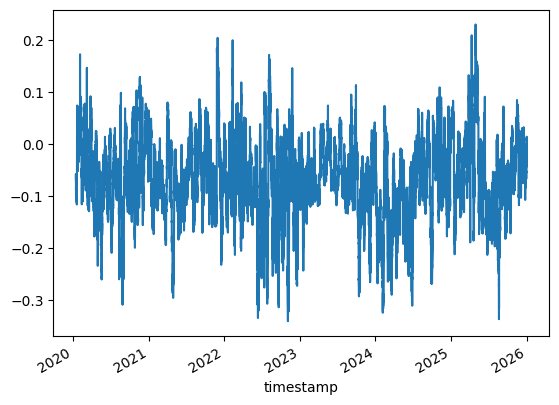

In [79]:
results['index_beta'].plot()

In [16]:
import itertools


def sweep_parameters(
    df_base,
    tcost_bps=1.0,
    margin_multiples=np.arange(0.0, 2.0, 0.1),
    adjust_to_target_values=[True, False],
    pred_zs_thresholds=np.arange(0.0, 2.0, 0.2),
):
    results = []

    for margin_multiple, adjust_to_target, pred_zs_threshold in itertools.product(
        margin_multiples, adjust_to_target_values, pred_zs_thresholds
    ):
        df = df_base.copy()
        df = apply_position(
            df,
            tcost_bps=tcost_bps,
            margin_multiple=margin_multiple,
            adjust_to_target=adjust_to_target,
            pred_zs_threshold=pred_zs_threshold,
            delay_trade_on_signal=False
        )

        df["frictionless_pnl"] = df["target_position"].shift(1) * df["ret"]
        df["gross_pnl"] = df["position"].shift(1) * df["ret"]
        df["net_pnl"] = (
            df["gross_pnl"] - 0.5 * df["tcost"] * df["position"].diff().abs()
        )

        results.append(
            {
                "margin_multiple": margin_multiple,
                "adjust_to_target": adjust_to_target,
                "pred_zs_threshold": pred_zs_threshold,
                "net_sharpe": sharpe(df["net_pnl"]),
                "gross_sharpe": sharpe(df["gross_pnl"]),
                "frictionless_sharpe": sharpe(df["frictionless_pnl"].dropna()),
            }
        )

    sweep = pd.DataFrame(results).sort_values("net_sharpe", ascending=False)
    return sweep


# --- Run sweep ---
# Build base df once (avoid recomputing regression)
past_horizon = pd.Timedelta(hours=3)
future_horizon = pd.Timedelta(hours=1)
lookback_window = pd.Timedelta(days=5)

df_base = rolling_return_regression(ret_series, past_horizon, future_horizon, lookback_window)
df_base = df_base.join(ret_series.rename("ret"), how="left")

sweep = sweep_parameters(df_base, tcost_bps=2.0)

# --- Best parameter set ---
best = sweep.iloc[0]
print(sweep.to_string(index=False))
print(
    f"\nBest: margin_multiple={best['margin_multiple']}, "
    f"adjust_to_target={best['adjust_to_target']}, "
    f"pred_zs_threshold={best['pred_zs_threshold']}, "
    f"net_sharpe={best['net_sharpe']:.2f}, "
)

 margin_multiple  adjust_to_target  pred_zs_threshold  net_sharpe  gross_sharpe  frictionless_sharpe
             0.5              True                0.2    1.977446      4.015719             6.351785
             0.3             False                1.0    1.964716      3.358026             5.792986
             0.3             False                1.2    1.956994      3.331029             5.562722
             0.3             False                0.8    1.943966      3.397981             6.105427
             0.9              True                0.4    1.936372      2.745481             6.288948
             0.9              True                0.6    1.933658      2.733730             6.317721
             0.5              True                0.0    1.914625      3.896045             6.423536
             0.3             False                0.6    1.903835      3.367539             6.317721
             0.4             False                1.2    1.893867      2.851393            

In [48]:
import itertools


def sweep_parameters_panel(
    df_base,
    tcost_bps=1.0,
    margin_multiples=np.arange(0.0, 2.0, 0.1),
    adjust_to_target_values=[True, False],
    pred_zs_thresholds=np.arange(0.0, 2.0, 0.2),
):
    results = []

    for margin_multiple, adjust_to_target, pred_zs_threshold in itertools.product(
        margin_multiples, adjust_to_target_values, pred_zs_thresholds
    ):
        df = df_base.copy()
        df = apply_position(
            df,
            tcost_bps=tcost_bps,
            margin_multiple=margin_multiple,
            adjust_to_target=adjust_to_target,
            pred_zs_threshold=pred_zs_threshold,
            delay_trade_on_signal=False
        )

        df["frictionless_pnl"] = df["target_position"].shift(1) * df["ret"]
        df["gross_pnl"] = df["position"].shift(1) * df["ret"]
        df["net_pnl"] = (
            df["gross_pnl"] - 0.5 * df["tcost"] * df["position"].diff().abs()
        )

        results.append(
            {
                "margin_multiple": margin_multiple,
                "adjust_to_target": adjust_to_target,
                "pred_zs_threshold": pred_zs_threshold,
                "net_sharpe": sharpe(df["net_pnl"]),
                "gross_sharpe": sharpe(df["gross_pnl"]),
                "frictionless_sharpe": sharpe(df["frictionless_pnl"].dropna()),
            }
        )

    sweep = pd.DataFrame(results).sort_values("net_sharpe", ascending=False)
    return sweep


# --- Run sweep ---
# Build base df once (avoid recomputing regression)
past_horizon = pd.Timedelta(hours=2)
future_horizon = pd.Timedelta(minutes=15)
lookback_window = pd.Timedelta(days=5)

currency_ret_series = strategy.build_rets_vs_sgd()["EUR"]

df_base = rolling_panel_regression(index_ret_series, currency_ret_series, past_horizon, future_horizon, lookback_window)
df_base = df_base.join(currency_ret_series.rename("ret"), how="left")

sweep = sweep_parameters_panel(df_base, tcost_bps=1.0)

# --- Best parameter set ---
best = sweep.iloc[0]
print(sweep.to_string(index=False))
print(
    f"\nBest: margin_multiple={best['margin_multiple']}, "
    f"adjust_to_target={best['adjust_to_target']}, "
    f"pred_zs_threshold={best['pred_zs_threshold']}, "
    f"net_sharpe={best['net_sharpe']:.2f}, "
)

 margin_multiple  adjust_to_target  pred_zs_threshold  net_sharpe  gross_sharpe  frictionless_sharpe
             0.1              True                0.0    3.342174      5.204869             5.398858
             0.2              True                0.0    3.288763      4.775862             5.398858
             0.2              True                0.4    3.285554      4.862944             5.268957
             0.1              True                0.6    3.277095      5.105667             5.188709
             0.1              True                0.4    3.271508      5.160976             5.268957
             0.1              True                1.0    3.268926      4.860309             4.901317
             0.1              True                0.2    3.266834      5.195149             5.344951
             0.1              True                0.8    3.266168      5.004009             5.064394
             0.2              True                0.6    3.265802      4.860910            

In [81]:
signals = strategy.generate_signals()

In [82]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(instruments, prices, signals)

report = PerformanceReport(instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
USDSGD,0.802288,0.803354,23.539023,-0.000011,-0.000006,0.0,0.0,0 days 00:43:53.568863,0 days 00:15:00,0 days 00:15:00,0 days 01:00:00
EURUSD,-0.333253,-0.333196,7.764733,-0.000018,-0.000002,-0.0,-0.0,0 days 01:06:43.988462,0 days 00:30:00,0 days 00:15:00,0 days 01:45:00
AUDUSD,-0.148054,-0.147891,4.589498,-0.000023,-0.00002,-0.0,-0.0,0 days 02:00:51.862368,0 days 00:45:00,0 days 00:15:00,0 days 02:45:00
GBPUSD,-0.574917,-0.574807,6.766773,-0.000044,-0.000011,-0.0,-0.0,0 days 01:15:00.923919,0 days 00:30:00,0 days 00:15:00,0 days 02:00:00
USDJPY,-0.82611,-0.826033,8.520767,-0.000068,-0.000011,-0.0,-0.0,0 days 01:00:32.996512,0 days 00:30:00,0 days 00:15:00,0 days 01:30:00


<Axes: title={'center': 'USDSGD Cumulative PnL'}, xlabel='Time', ylabel='Cumulative PnL'>

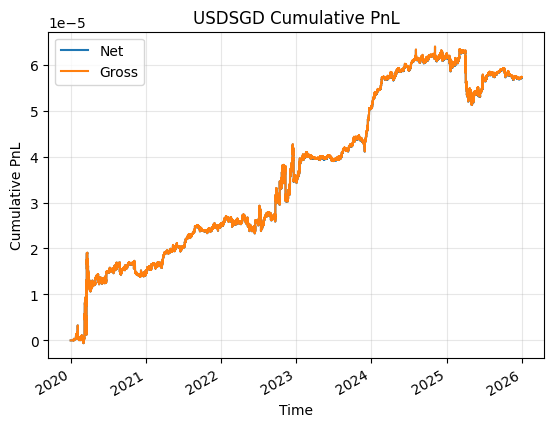

In [50]:
report.plot_cumulative_pnl('USDSGD')

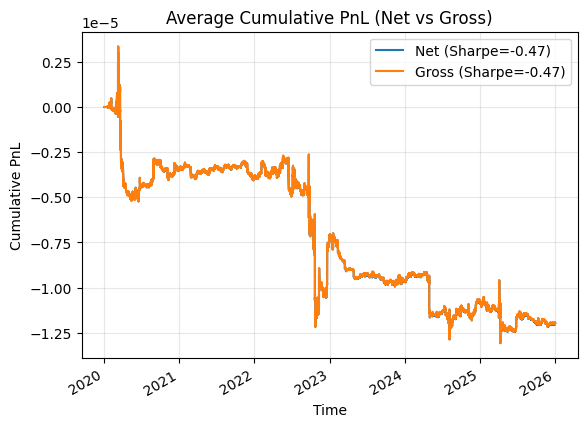

In [49]:
import numpy as np

freq_mult = pd.Timedelta(days=1) / freq

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * freq_mult) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * freq_mult) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [307]:
rets_vs_sgd = strategy.build_rets_vs_sgd()

In [19]:
rolling_windows_mins = [15, 30, 60, 120]
fwd_periods_mins = [15, 30, 60]

zscore_window_mins = 120

bar_minutes = int(freq / pd.Timedelta(minutes=1))

rolling_windows = [x // bar_minutes for x in rolling_windows_mins]
fwd_periods = [x // bar_minutes for x in fwd_periods_mins]
zscore_window = zscore_window_mins // bar_minutes

zscore_bins = [
    (0, 0.5),
    (0.5, 1),
    (1, 2),
    (2, np.inf),
]

results = []

for rolling_window_mins, rolling_window in zip(rolling_windows_mins, rolling_windows):
    for fwd_period_mins, fwd_period in zip(fwd_periods_mins, fwd_periods):
        for ccy in ccys + ["index"]:
            past_ret = rets_vs_sgd[ccy].rolling(rolling_window).sum()

            past_z = (
                (past_ret - past_ret.rolling(zscore_window).mean())
                / past_ret.rolling(zscore_window).std()
            )

            future_ccy_ret = (
                rets_vs_sgd[ccy]
                .rolling(fwd_period)
                .sum()
                .shift(-fwd_period)
            )

            abs_z = past_z.abs()

            for lower, upper in zscore_bins:
                if np.isinf(upper):
                    bucket_mask = abs_z > lower
                    z_bucket = f">{lower}"
                else:
                    bucket_mask = (abs_z >= lower) & (abs_z < upper)
                    z_bucket = f"{lower}-{upper}"

                beta, corr, n_obs = sn.regression_stats(
                    past_ret[bucket_mask],
                    future_ccy_ret[bucket_mask],
                )

                results.append({
                    "ccy": ccy,
                    "rolling_window_mins": rolling_window_mins,
                    "fwd_period_mins": fwd_period_mins,
                    "zscore_window_mins": zscore_window_mins,
                    "z_bucket": z_bucket,
                    "beta": beta,
                    "corr": corr,
                    "n_obs": n_obs,
                })

zscore_bucket_results = pd.DataFrame(results)

zscore_bucket_results.sort_values(
    ["rolling_window_mins", "fwd_period_mins", "ccy", "z_bucket"]
)


,ccy,rolling_window_mins,fwd_period_mins,zscore_window_mins,z_bucket,beta,corr,n_obs
8,AUD,15,15,120,0-0.5,-0.042372,-0.018748,54195
9,AUD,15,15,120,0.5-1,-0.021581,-0.016673,42482
10,AUD,15,15,120,1-2,-0.041169,-0.055599,39913
11,AUD,15,15,120,>2,-0.042297,-0.092520,3235
4,EUR,15,15,120,0-0.5,-0.089794,-0.039149,54678
...,...,...,...,...,...,...,...,...
267,USD,120,60,120,>2,-0.039060,-0.059510,5192
284,index,120,60,120,0-0.5,-0.033393,-0.036546,38236
285,index,120,60,120,0.5-1,-0.059438,-0.074805,41369
286,index,120,60,120,1-2,-0.081819,-0.119864,63155


In [222]:
zscore_bucket_results.pivot_table(
    index=["rolling_window_mins", "fwd_period_mins", "ccy"],
    columns="z_bucket",
    values="corr",
).to_clipboard()


<Axes: xlabel='timestamp'>

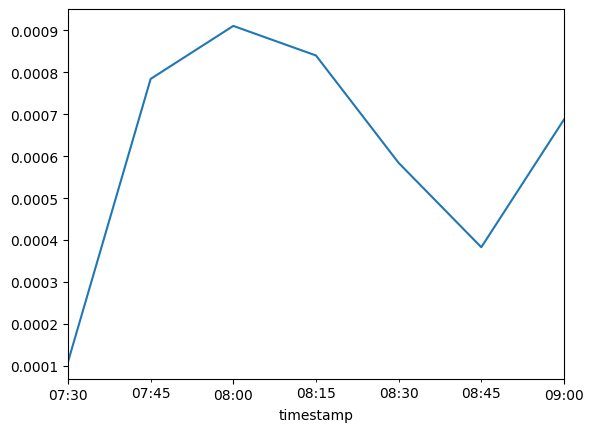

In [13]:
rets.loc['2025-07-03 07:30' : '2025-07-03 09:00']['index'].cumsum().plot()

In [20]:
past_horizon = pd.Timedelta(minutes=60)
future_horizon = pd.Timedelta(minutes=5)
lookback_window = pd.Timedelta(days=5)

p = int(past_horizon / freq)
f = int(future_horizon / freq)
w = int(lookback_window / freq)

rets_vs_sgd = strategy.build_rets_vs_sgd()
results = rets_vs_sgd.copy()

for ccy in ccys + ["index"]:

    past_ret = rets_vs_sgd[ccy].rolling(p).sum()
    past_relative_ret = (rets_vs_sgd[ccy] - rets_vs_sgd["index"]).rolling(p).sum()

    past_z = (
        (past_ret - past_ret.rolling(w).mean())
        / past_ret.rolling(w).std()
    )

    past_relative_z = (
        (past_relative_ret - past_relative_ret.rolling(w).mean())
        / past_relative_ret.rolling(w).std()
    )

    future_ccy_ret = (
        rets_vs_sgd[ccy]
        .rolling(f)
        .sum()
        .shift(-f)
    )

    results[ccy + "_past_ret"] = past_ret
    results[ccy + "_past_z"] = past_z
    results[ccy + "_past_relative_ret"] = past_relative_ret
    results[ccy + "_past_relative_z"] = past_relative_z

In [23]:
results

,index,USD,EUR,JPY,AUD,GBP,USD_past_ret,USD_past_z,USD_past_relative_ret,USD_past_relative_z,...,GBP_past_relative_ret,GBP_past_relative_z,JPY_past_ret,JPY_past_z,JPY_past_relative_ret,JPY_past_relative_z,index_past_ret,index_past_z,index_past_relative_ret,index_past_relative_z
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 17:30:00-05:00,-0.000100,-1.858719e-05,-0.000152,-0.000313,0.000195,-0.000517,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 17:45:00-05:00,-0.000216,-1.932863e-04,-0.000224,-0.000478,0.000056,-0.000008,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 18:00:00-05:00,-0.000325,-4.124669e-04,-0.000341,-0.000316,-0.000070,-0.000186,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 18:15:00-05:00,-0.000058,3.604347e-04,-0.000108,0.000071,-0.001386,-0.000134,-0.000264,NaN,0.000435,NaN,...,-0.000146,NaN,-0.001037,NaN,-0.000338,NaN,-0.000699,NaN,0.0,NaN
2020-01-01 18:30:00-05:00,0.000115,4.831555e-05,-0.000032,0.000343,0.000276,0.000305,-0.000197,NaN,0.000287,NaN,...,0.000460,NaN,-0.000381,NaN,0.000103,NaN,-0.000484,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 15:45:00-05:00,0.000114,1.905825e-04,0.000110,0.000120,-0.000064,-0.000091,0.000502,1.243254,0.000291,1.010470,...,-0.001183,-2.421985,-0.000012,-0.059893,-0.000222,-0.481252,0.000210,0.706458,0.0,NaN
2025-12-31 16:00:00-05:00,-0.000130,-1.665335e-16,-0.000315,-0.000233,0.000090,-0.000271,0.000611,1.514583,0.000466,1.579507,...,-0.001049,-2.135604,-0.000130,-0.273826,-0.000275,-0.595450,0.000145,0.483350,0.0,NaN
2025-12-31 16:15:00-05:00,0.000170,3.889817e-06,0.000370,0.000301,0.000026,0.000171,0.000354,0.915634,0.000168,0.632794,...,-0.000519,-1.055733,-0.000070,-0.175030,-0.000256,-0.576539,0.000186,0.627822,0.0,NaN


In [22]:
zs_mask = results["index_past_z"].abs() > 2.0
results[zs_mask].filter(like="_z")

,USD_past_z,USD_past_relative_z,EUR_past_z,EUR_past_relative_z,AUD_past_z,AUD_past_relative_z,GBP_past_z,GBP_past_relative_z,JPY_past_z,JPY_past_relative_z,index_past_z,index_past_relative_z
timestamp,,,,,,,,,,,,
2020-01-12 18:45:00-05:00,1.524132,-1.152601,2.070889,0.740385,0.717278,-0.358940,1.739637,0.850230,1.173186,0.496027,2.349514,NaN
2020-01-14 02:15:00-05:00,-2.402003,0.449077,-2.015933,-0.142006,-1.405608,-0.007388,0.610553,1.704954,-1.442065,-0.671067,-2.679384,NaN
2020-01-14 06:15:00-05:00,-1.910667,0.313401,-1.422144,0.117837,-0.322250,0.687212,-2.414187,-1.616650,-1.093065,-0.484914,-2.061302,NaN
2020-01-20 03:30:00-05:00,-2.698909,-0.704659,-1.045881,0.459316,0.547774,1.477116,-0.154758,0.599700,-2.142365,-1.407967,-2.384200,NaN
2020-01-20 20:30:00-05:00,-2.426758,-0.635890,-0.902891,0.548995,2.426382,3.282849,-0.345088,0.363857,-3.818665,-3.662957,-2.212423,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 11:30:00-05:00,2.935612,2.153060,0.945767,-0.501467,-0.015008,-1.141883,-0.340720,-1.734322,-0.113791,-1.135148,2.037058,NaN
2025-12-30 18:30:00-05:00,1.623652,-0.058467,1.694821,0.099461,0.994881,-0.317196,1.590846,0.135602,1.340164,0.162431,2.512144,NaN
2025-12-31 02:45:00-05:00,-2.066114,-0.145858,-1.539922,0.482735,-1.623798,-0.134733,-1.513165,0.294729,-1.644306,-0.235641,-2.893925,NaN


In [98]:
results.filter(like="past_z").to_clipboard()